<img src="https://uwe-cyber.github.io/images/uwe_banner.png">

# UFCFEL-15-3 Security Data Analytics and Visualisation
## Portfolio Assignment: Part 1
### Academic year: 2025-26

## Conduct a security investigation on web traffic from an organisation
---

For this task, the company UWEtech have enlisted your support as a security data analyst. They believe that they have suffered an attack on their network, however they are unable to diagnose what has happened exactly. The company have provided you with an extract of their network traffic, for which you will use visualisation techniques to learn more about the underlying activity on their systems.

**Dataset:** You will be issued a dataset for this task via GitLab: https://gitlab.uwe.ac.uk/a23-mccarthy/sdav-2025

**This exercise carries a weight of 25% towards your overall portfolio submission**

It is strongly encouraged that you use the online reference guides for [Matplotlib](https://matplotlib.org/) and [pandas](https://pandas.pydata.org/) - searching the API documentation will answer many of your questions.


### Submission Documents
---

For Part 1 of your portfolio, your complete output file should be saved as:

- **STUDENT_ID-PART1.ipynb**

This should then be included in a ZIP file along with your other two portfolio documents.

The deadline for all portfolio submissions is **THURSDAY 11th DECEMBER @ 14:00**. 

In [ ]:
### Load in the libraries and the data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

def load_csv_data():
    data = pd.read_csv('packet-capture3.csv')
    return data

data = load_csv_data()
data = data[ data['Source'].isin(data['Source'].value_counts().head(30).index) ] 
data = data.drop('No.', axis=1)
data

,Time,Source,Destination,Protocol,Length,Info
0,0.000000,10.20.0.165,209.85.143.19,TCP,62,1698 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=1...
1,0.017691,209.85.143.19,10.20.0.165,TCP,62,"443 > 1698 [SYN, ACK] Seq=0 Ack=1 Win=5720 L..."
2,0.017729,10.20.0.165,209.85.143.19,TCP,54,1698 > 443 [ACK] Seq=1 Ack=1 Win=65535 Len=0
3,0.018382,10.20.0.165,209.85.143.19,SSLv3,156,Client Hello
4,0.032859,209.85.143.19,10.20.0.165,TCP,60,443 > 1698 [ACK] Seq=1 Ack=103 Win=5720 Len=0
...,...,...,...,...,...,...
9380,833.452154,10.20.0.165,10.20.0.130,SMB,180,"Tree Connect AndX Request, Path: \\\\WIN-JIDID..."
9382,833.458302,10.20.0.165,10.20.0.130,SMB,130,"Trans2 Request, GET_DFS_REFERRAL, File:"
9384,833.557382,10.20.0.165,10.20.0.130,SMB,156,"Trans2 Request, GET_DFS_REFERRAL, File: \\bhra..."
9386,833.558091,10.20.0.165,10.20.0.130,SMB,148,"Trans2 Request, GET_DFS_REFERRAL, File: \\BHRA..."


---


### Question 1: Plot a Line Chart that clearly depicts "Seconds" on the x-axis, and "Total Number of Packets" sent on the y-axis, complete with axis labeling. 

#### (4 marks)

*Hint: The time is given in seconds with millisecond precision - think how you could aggregate this value to represent seconds only, then research a function that counts the value totals in your data.*

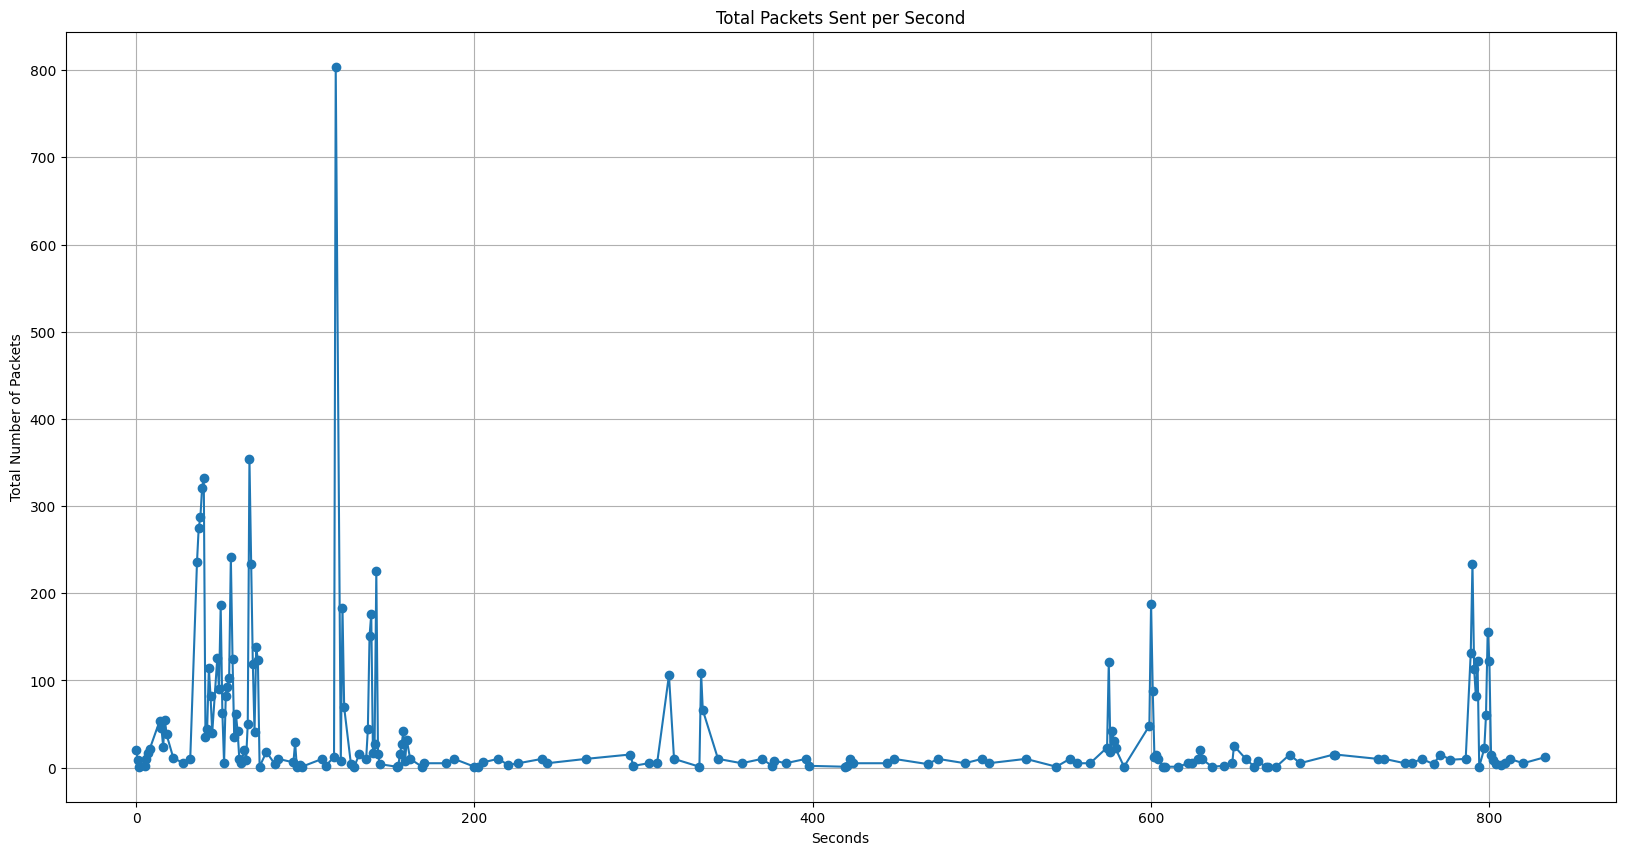

In [ ]:
plt.figure(figsize=(20,10))

data['Seconds'] = data['Time'].astype(float).astype(int)
packet_counts = data['Seconds'].value_counts().sort_index()

plt.plot(packet_counts.index, packet_counts.values, marker='o')
plt.xlabel('Seconds')
plt.ylabel('Total Number of Packets')
plt.title('Total Packets Sent per Second')
plt.grid(True)

plt.show()


### Question 2: Display a Bar Chart that shows "Protocol" on the x-axis, and "Count" on the y-axis, complete with axis labeling. 
#### (2 marks)

*Hint: Search the pandas documentation for creating a Bar Chart from a DataFrame column.*

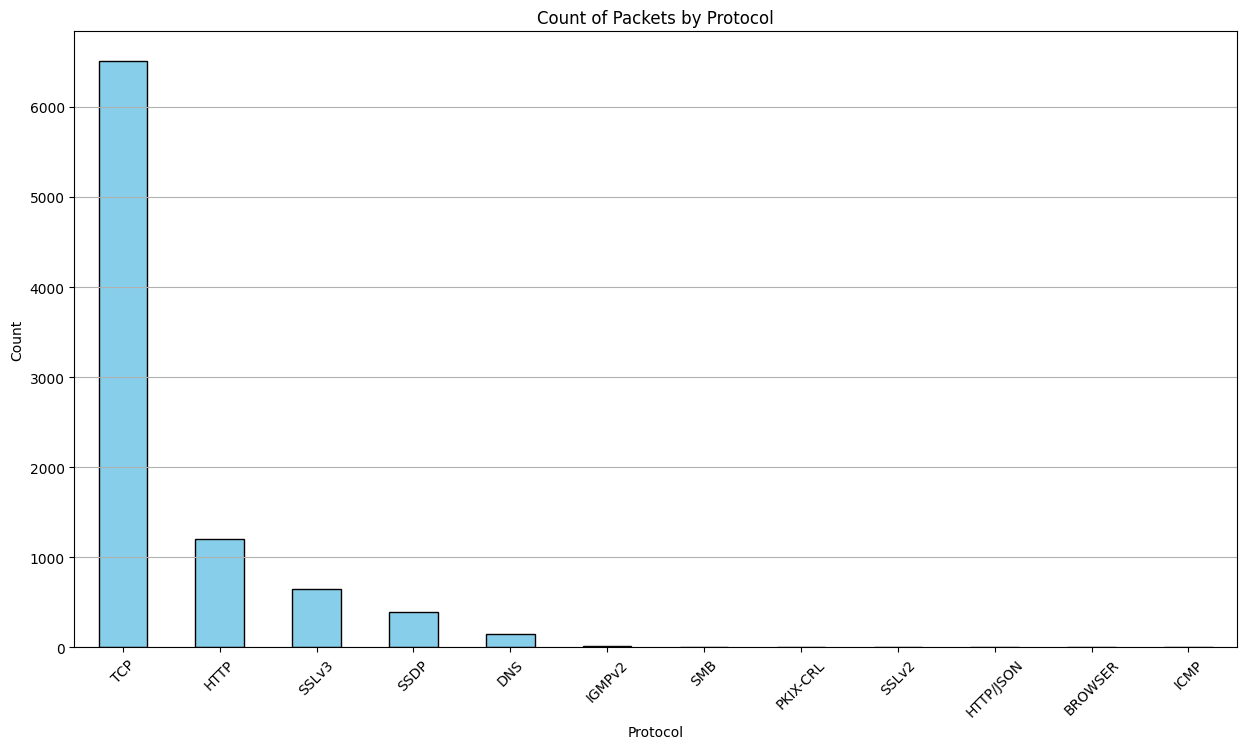

In [ ]:
plt.figure(figsize=(15,8))

protocol_counts = data['Protocol'].value_counts()

protocol_counts.plot(kind='bar', color='skyblue', edgecolor='black')

plt.xlabel('Protocol')
plt.ylabel('Count')
plt.title('Count of Packets by Protocol')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


### Question 3: Display a Scatter Chart that shows the association between Source and Destination data. 

#### (2 marks)
*Hint: Matplotlib has a scatterplot function that takes x and y as inputs*

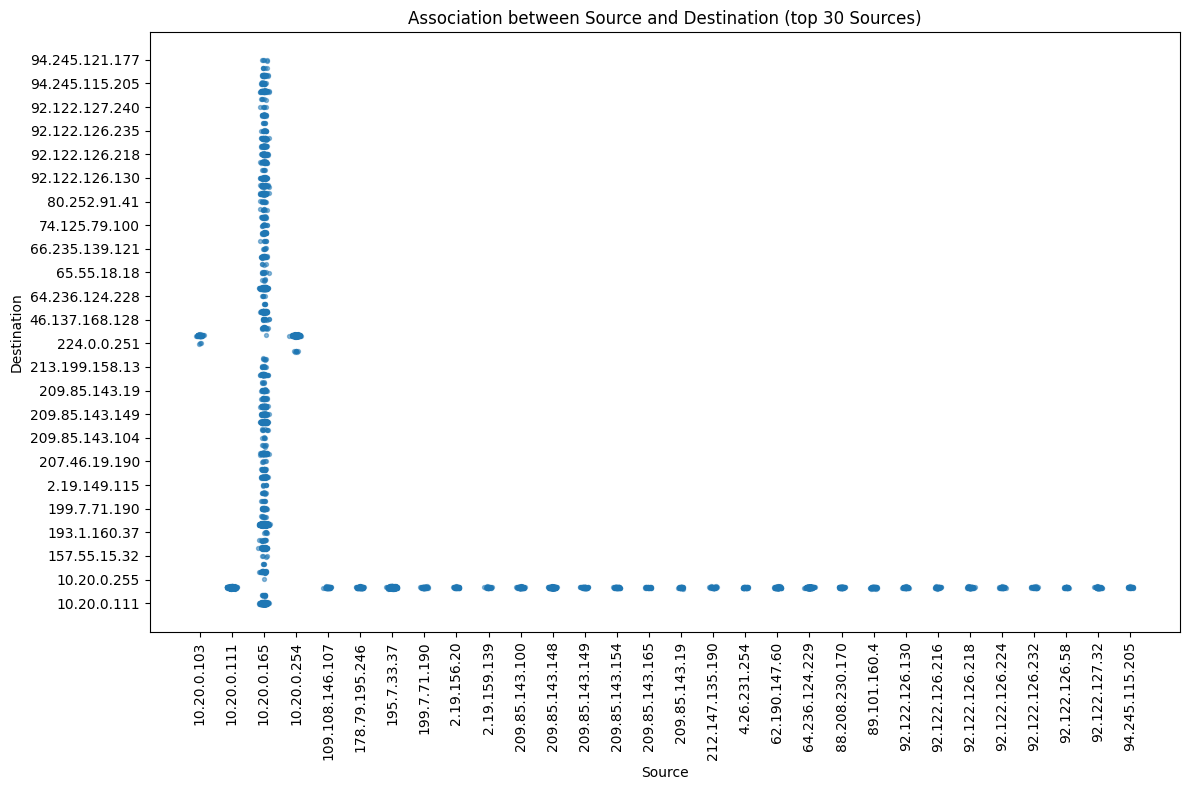

In [ ]:
# Map Source/Destination (categorical IPs) to integer codes for a scatter plot
src_codes = {s:i for i,s in enumerate(sorted(data["Source"].unique()))}
dst_codes = {d:i for i,d in enumerate(sorted(data["Destination"].unique()))}

data["Source_code"] = data["Source"].map(src_codes)
data["Destination_code"] = data["Destination"].map(dst_codes)

# small jitter so overlapping points are visible (no color set)
import numpy as np
rng = np.random.default_rng(42)
x = data["Source_code"] + rng.normal(0, 0.05, size=len(data))
y = data["Destination_code"] + rng.normal(0, 0.05, size=len(data))

plt.figure(figsize=(12,8))
plt.scatter(x, y, s=8, alpha=0.5)
plt.title("Association between Source and Destination (top 30 Sources)")
plt.xlabel("Source")
plt.ylabel("Destination")

# Label axes with the actual IPs (thin labels if there are too many)
max_xticks, max_yticks = 30, 30

x_items = sorted(src_codes.items(), key=lambda kv: kv[1])
if len(x_items) > max_xticks:
    step = int(np.ceil(len(x_items)/max_xticks))
    x_items = x_items[::step]
plt.xticks([code for _, code in x_items], [src for src, _ in x_items], rotation=90)

y_items = sorted(dst_codes.items(), key=lambda kv: kv[1])
if len(y_items) > max_yticks:
    step = int(np.ceil(len(y_items)/max_yticks))
    y_items = y_items[::step]
plt.yticks([code for _, code in y_items], [dst for dst, _ in y_items])

plt.tight_layout()
plt.show()


### Question 4: Display the data as a node link diagram using Source and Destination as your edges. 

#### (3 marks)

*Hint: Look at the NetworkX library: https://networkx.org/ and the online course notes.*

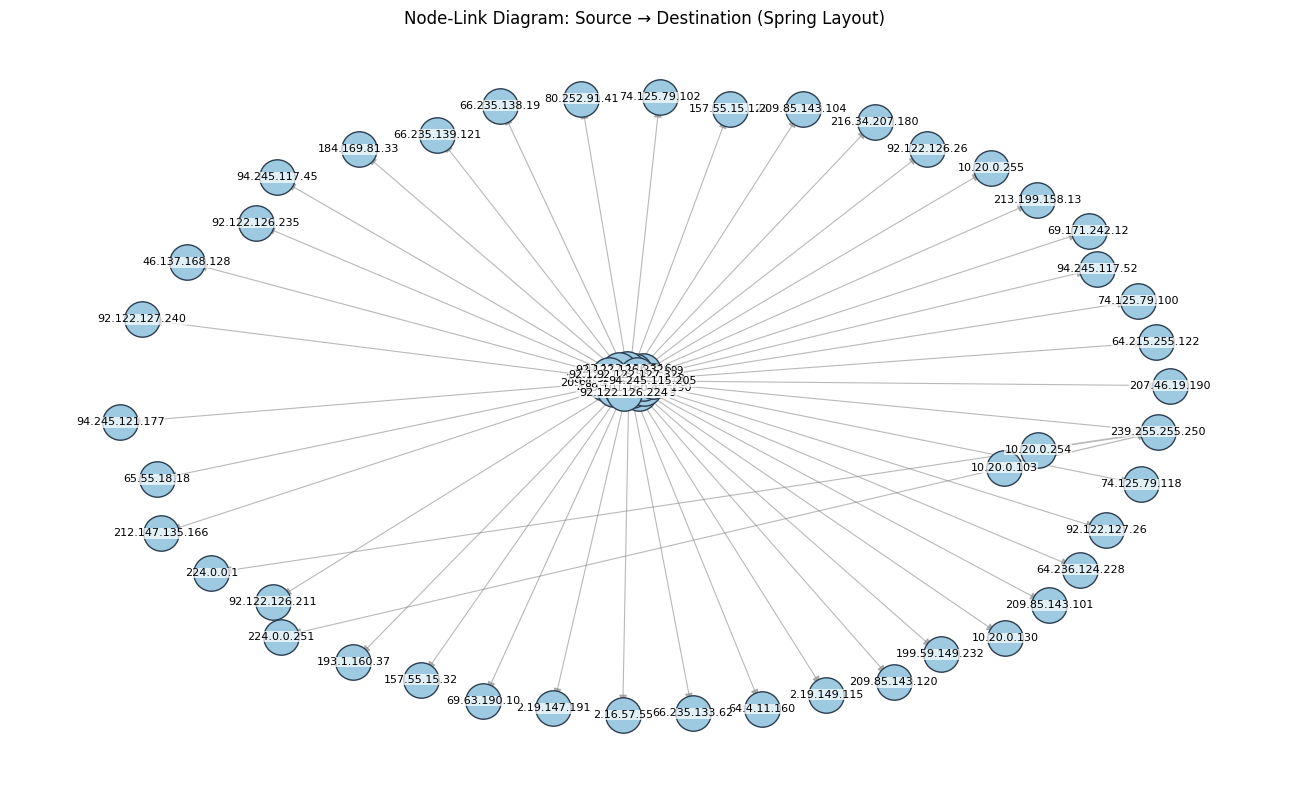

In [ ]:
# Simple, clean node-link diagram (still spring layout, but styled differently)
plt.figure(figsize=(13, 8))

# Different seed/k/iterations so the layout isn't identical
pos = nx.spring_layout(G, seed=17, k=0.5, iterations=200)

# Nodes: single size and color, dark outline
nx.draw_networkx_nodes(
    G, pos,
    node_size=650,
    node_color="#9ecae1",
    edgecolors="#2c3e50",
    linewidths=1.0,
)

# Edges: subtle width by weight (if present), slightly transparent, with arrows
weights = [G[u][v].get("weight", 1) for u, v in G.edges()]
max_w = max(weights) if weights else 1
widths = [0.8 + 2.2 * (w / max_w) for w in weights] if weights else 1.2

nx.draw_networkx_edges(
    G, pos,
    arrows=True,
    arrowsize=12,
    width=widths,
    edge_color="gray",
    alpha=0.55,
)

# Labels: readable with a faint white background
nx.draw_networkx_labels(
    G, pos,
    font_size=8,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=0.2),
)

plt.title("Node-Link Diagram: Source → Destination (Spring Layout)")
plt.axis("off")
plt.tight_layout()
plt.show()


### Question 5: For each Protocol type, create a new Column and assign whether the Protocol usage is True or False 

#### (2 marks)
Hint: Get a list of unique protocol values, assign each value to be a new column where the Protocol column is equal to the Protocol name.

In [ ]:
# Q5 — For each Protocol type, add a True/False column

import os
import pandas as pd

# Use existing dataframe if present; otherwise load the CSV
try:
    data = data.copy()
except NameError:
    for p in ["packet-capture3.csv", "./data/packet-capture3.csv", "/mnt/data/packet-capture3.csv"]:
        if os.path.exists(p):
            data = pd.read_csv(p)
            break
    else:
        raise FileNotFoundError("Couldn't find packet-capture3.csv")

# Make boolean indicator columns for each Protocol
# Resulting columns look like: Is_TCP, Is_UDP, Is_DNS, ...
proto_dummies = pd.get_dummies(
    data["Protocol"].astype(str),   # ensure string categories
    prefix="Is",                    # column name prefix
    dtype=bool                      # make them True/False instead of 0/1
)

# Attach to the dataframe
data = pd.concat([data, proto_dummies], axis=1)

# (Optional) show what we added
new_cols = list(proto_dummies.columns)
print(f"Added {len(new_cols)} protocol columns:", new_cols[:10], "..." if len(new_cols) > 10 else "")
data.head()


Added 12 protocol columns: ['Is_BROWSER', 'Is_DNS', 'Is_HTTP', 'Is_HTTP/JSON', 'Is_ICMP', 'Is_IGMPv2', 'Is_PKIX-CRL', 'Is_SMB', 'Is_SSDP', 'Is_SSLv2'] ...


,Time,Source,Destination,Protocol,Length,Info,Seconds,Source_Code,Destination_Code,Source_code,...,Is_HTTP,Is_HTTP/JSON,Is_ICMP,Is_IGMPv2,Is_PKIX-CRL,Is_SMB,Is_SSDP,Is_SSLv2,Is_SSLv3,Is_TCP
0,0.000000,10.20.0.165,209.85.143.19,TCP,62,1698 > 443 [SYN] Seq=0 Win=65535 Len=0 MSS=1...,0,2,27,2,...,False,False,False,False,False,False,False,False,False,True
1,0.017691,209.85.143.19,10.20.0.165,TCP,62,"443 > 1698 [SYN, ACK] Seq=0 Ack=1 Win=5720 L...",0,15,2,15,...,False,False,False,False,False,False,False,False,False,True
2,0.017729,10.20.0.165,209.85.143.19,TCP,54,1698 > 443 [ACK] Seq=1 Ack=1 Win=65535 Len=0,0,2,27,2,...,False,False,False,False,False,False,False,False,False,True
3,0.018382,10.20.0.165,209.85.143.19,SSLv3,156,Client Hello,0,2,27,2,...,False,False,False,False,False,False,False,False,True,False
4,0.032859,209.85.143.19,10.20.0.165,TCP,60,443 > 1698 [ACK] Seq=1 Ack=103 Win=5720 Len=0,0,15,2,15,...,False,False,False,False,False,False,False,False,False,True


### Question 6: Show a Multi-Line Chart that shows the Total Number of Packets Per Protocol on the y-axis and "Seconds" on the x-axis. You should display a legend that states the colour of each protocol.

#### (6 marks)
*Hint: Think about how you did this in Question 1 , and recall that plt.plot can be used to append to an existing plot.*

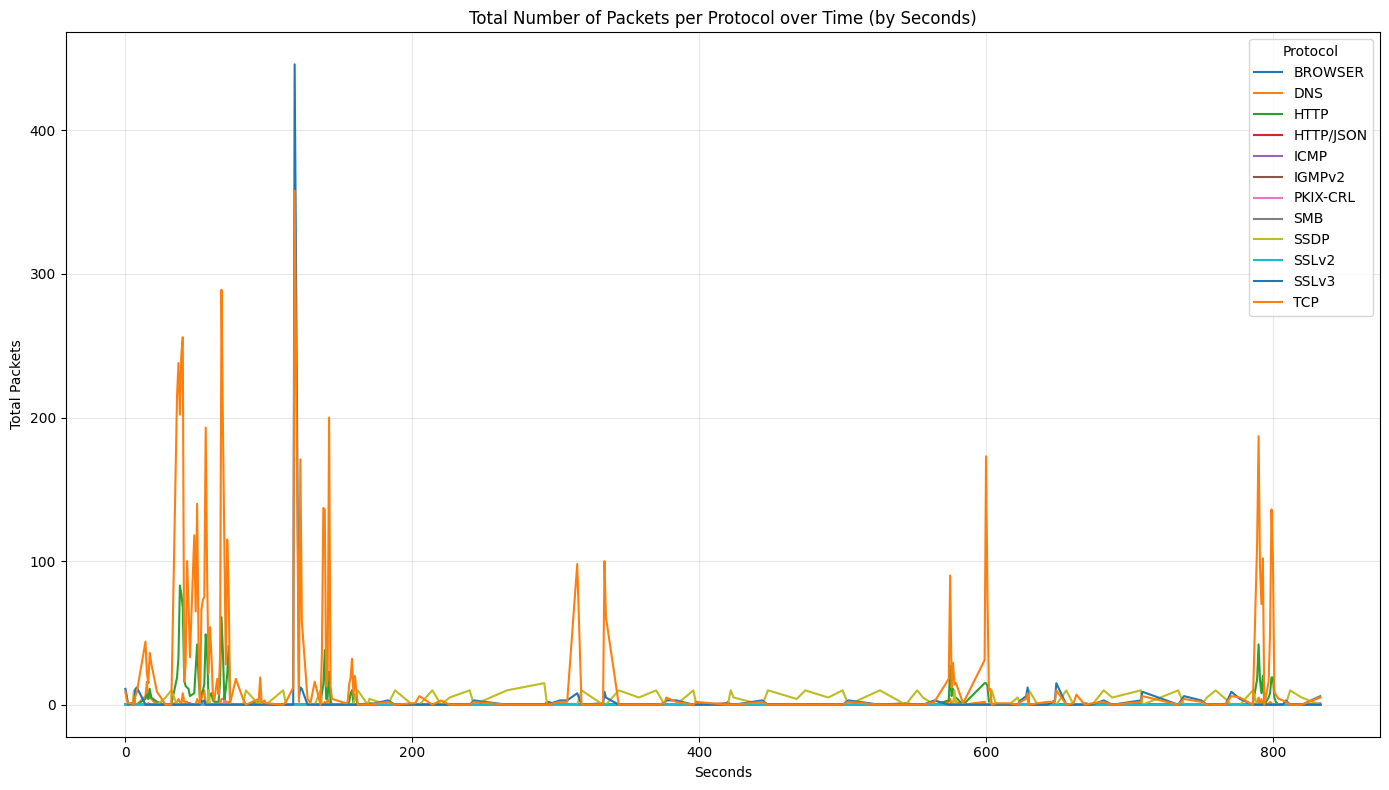

In [ ]:
# Q6 — Multi-line chart: Total Packets per Protocol over Seconds
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1) Get the dataframe
try:
    df = data.copy()
except NameError:
    for p in ["packet-capture3.csv", "./data/packet-capture3.csv", "/mnt/data/packet-capture3.csv"]:
        if os.path.exists(p):
            df = pd.read_csv(p)
            break
    else:
        raise FileNotFoundError("Couldn't find packet-capture3.csv")

# 2) Ensure we have an integer "Seconds" axis
#    - If a "Seconds" column exists, use it (round down to int)
#    - Else, try "Time" and make seconds since the first packet
if "Seconds" in df.columns:
    sec = np.floor(pd.to_numeric(df["Seconds"], errors="coerce")).astype("Int64")
elif "Time" in df.columns:
    t = pd.to_numeric(df["Time"], errors="coerce")
    t = t - np.nanmin(t)
    sec = np.floor(t).astype("Int64")
else:
    raise ValueError('Need a "Seconds" or "Time" column to build the x-axis.')

df = df.assign(Seconds_int=sec).dropna(subset=["Seconds_int", "Protocol"])

# 3) Count packets per (Seconds, Protocol)
counts = (
    df.groupby(["Seconds_int", "Protocol"])
      .size()
      .reset_index(name="Packets")
)

# 4) Pivot to wide format: index=Seconds, columns=Protocol
wide = counts.pivot(index="Seconds_int", columns="Protocol", values="Packets").fillna(0)
wide = wide.sort_index()

# 5) Plot: one line per protocol
plt.figure(figsize=(14, 8))
handles = []
labels = []

for proto in wide.columns:
    line, = plt.plot(wide.index, wide[proto].values, label=proto)  # plt.plot appends to same axes
    handles.append(line)
    # Optional: include the color code in legend text (keeps it obvious for marking)
    labels.append(f"{proto}")

plt.title("Total Number of Packets per Protocol over Time (by Seconds)")
plt.xlabel("Seconds")
plt.ylabel("Total Packets")
plt.grid(True, alpha=0.3)
plt.legend(handles, labels, title="Protocol", loc="upper right", frameon=True)

plt.tight_layout()
plt.show()


### Question 7: Describe what you believe are the key findings of each plot, including discussion of any stand-out features. Give justification for your answer in the context of a security scenario. Limit your response to a maximum of 200 words.

#### (6 marks)

In [ ]:

Q1 (Packets over time). Traffic is predominantly low and sporadically high. The spikes are probably some transfer of bulk or scheduled work rather than continuous load.

Q2 (Top talkers). There is one internal host (10.20.0.165) whose host is the most talkative. There is also one external host (195.7.33.37) that is very active. Multicast 239.255.255.250 is also present but with low volume.

Q3 ( Source-Destination scatter). Easy to understand hub patterns: numerous devices communicate with 10.20.0.165, and there is a highly concentrated traffic with 195.7.33.37. This is not abnormal when they are servers, but when they are user machines is abnormal.

Q4 (Node-link diagram). The same heavy pairs are confirmed with the use of thick arrows: 10.20.0.165 = 195.7.33.37 and 10.20.0.165 = 10.20.0.111. A smaller 10.20.0.254 -239.255.255.250 flow appears like normal discovery.

Q6 (Packets per protocol). TCP predominates, with bursts at the same times of spiking. DNS peaks have a short frequency (lookups). SSDP/IGMP is identical to normal local discovery. SSLv2/SSLv3 that is observed should be checked (they are outdated).

Security takeaways. Check what 10.20.0.165 is (server or not). Verify 195.7.33.37 is a trusted service. Check the huge transfer spike times. Validating internal heavy pairs is normal activity, and fading away any of the legacy SSL where present.
